Using dataset: /kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv


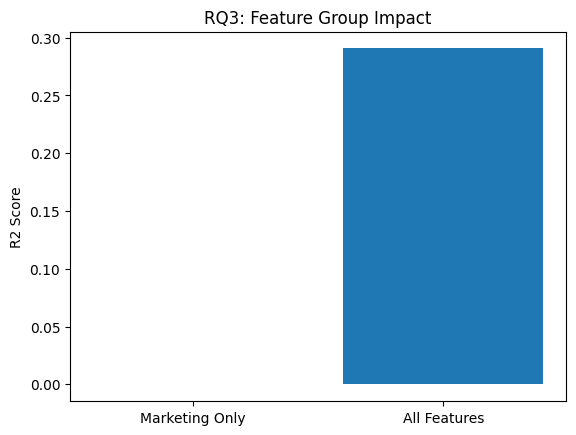

In [2]:
# RQ3 Notebook (Optimized for Kaggle - Fast & Robust)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# --------- Auto-detect dataset path ---------
DATA_PATH = "/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv"
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            DATA_PATH = os.path.join(dirname, filename)

print("Using dataset:", DATA_PATH)

# --------- Load dataset ---------
df = pd.read_csv(DATA_PATH)

# Reduce dataset size for speed
if len(df) > 3000:
    df = df.sample(n=3000, random_state=42)

# Basic preprocessing
df = df.dropna()
df = pd.get_dummies(df, drop_first=True)

# Target variable
target_col = "Sales" if "Sales" in df.columns else df.columns[-1]

X = df.drop(target_col, axis=1)
y = df[target_col]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Evaluation function
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

# --------- Feature group selection ---------
marketing_cols = [c for c in X.columns if any(x in c.lower() for x in ["ad", "campaign", "channel"])]

# Fallback if empty
if len(marketing_cols) == 0:
    print("No marketing-specific columns found, using first 5 features instead.")
    marketing_cols = X.columns[:5]

X_marketing = X[marketing_cols]

Xm_train, Xm_test, ym_train, ym_test = train_test_split(X_marketing, y, test_size=0.2, random_state=42)

# --------- Fast Random Forest ---------
model = RandomForestRegressor(
    n_estimators=30,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

# Train on marketing features
model.fit(Xm_train, ym_train)
m1 = evaluate(ym_test, model.predict(Xm_test))

# Train on all features
model.fit(X_train, y_train)
m2 = evaluate(y_test, model.predict(X_test))

# --------- Save results ---------
df_results = pd.DataFrame([
    ["Marketing Only", *m1],
    ["All Features", *m2]
], columns=["Setup","MAE","RMSE","R2"])

df_results.to_csv("RQ3_table.csv", index=False)

# --------- Plot ---------
plt.figure()
plt.bar(df_results["Setup"], df_results["R2"])
plt.title("RQ3: Feature Group Impact")
plt.ylabel("R2 Score")
plt.savefig("RQ3_figure.pdf")
plt.show()
